# Assignment 1 2AMM10 2025-2026

## Group: tokenmaxxing
### Member 1: Joana Lopes
### Member 2: Keanu
### Member 3: Melissa Maistro

## Task 1

Dataset and visualization

In [1]:
import os
import random
import re
from pathlib import Path
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
from torchvision import transforms
from PIL import Image
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import kagglehub
import torch
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

DEVICE = torch.device("mps"  if torch.backends.mps.is_available()  else
                       "cuda" if torch.cuda.is_available()          else
                       "cpu")
print("Using device:", DEVICE)


class AppleDataset(Dataset):
    def __init__(self, transform=None, subset="train",class_subset = "main"):
        assert subset in ["train","test"]
        assert class_subset in ["main","new","all"]
        path = kagglehub.dataset_download("moltean/fruits")
        base = Path(path) / "fruits-360_original-size" / "fruits-360-original-size"
        if subset == "train":
            self.path = base / "Training"
        elif subset == "test":
            self.path = base / "Validation"
        self.transform = transform
        all_folders = sorted(os.listdir(self.path))
        self.item_folders = sorted(x for x in all_folders if x.lower().startswith("apple"))
        generator=np.random.default_rng(6)
        generator.shuffle(self.item_folders)
        if class_subset == "main":
            self.item_folders = self.item_folders[:20]
        elif class_subset == "new":
            self.item_folders = self.item_folders[20:]
        self.targets = []
        self.image_paths = []
        for i, folder in enumerate(self.item_folders):
            for img_file in sorted(os.listdir(self.path / folder)):
                if img_file.startswith("r0"):
                    if class_subset=="new":
                        self.targets.append(i+20)
                    else:
                        self.targets.append(i)
                    self.image_paths.append(self.path / folder / img_file)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, i):
        image = Image.open(self.image_paths[i]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, self.targets[i]

dataset = AppleDataset()

item_dd = widgets.Dropdown(options=dataset.item_folders, description="Variety:")
frame_slider = widgets.IntSlider(value=0, min=0, max=0, description="Frame:")
output = widgets.Output()


def get_frames(folder):
    return sorted(f for f in os.listdir(dataset.path / folder)
                  if f.startswith("r0_") and f.endswith(".jpg"))

def update_slider(*_):
    frames = get_frames(item_dd.value)
    frame_slider.max = max(0, len(frames) - 1)
    frame_slider.value = min(frame_slider.value, frame_slider.max)
    show_image()

def show_image(*_):
    frames = get_frames(item_dd.value)
    if not frames or frame_slider.value >= len(frames):
        return
    with output:
        clear_output(wait=True)
        img = Image.open(dataset.path / item_dd.value / frames[frame_slider.value])
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(img)
        ax.set_title(f"{item_dd.value} | frame {frame_slider.value}")
        ax.axis("off")
        plt.tight_layout()
        plt.show()

item_dd.observe(update_slider, names="value")
frame_slider.observe(show_image, names="value")

update_slider()
display(widgets.VBox([item_dd, frame_slider, output]))

Using device: cuda


100%|██████████| 5.46G/5.46G [02:16<00:00, 42.8MB/s]

Extracting files...


In [2]:
# Transform data: resize + normalize
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


train_data = AppleDataset(subset="train",transform=transform)
test_data = AppleDataset(subset="test",transform=transform)
support_new_data = AppleDataset(subset="train",transform=transform,class_subset="new")
test_new_data = AppleDataset(subset="test",transform=transform,class_subset="new")




In [3]:
# Balanced batch sampler (P classes × K images per batch)
class BalancedBatchSampler(Sampler):
    """
    Each batch contains exactly P classes, each represented by K images.
    Batch size = P * K.

    Why: Triplet loss needs multiple images per class in a batch so we can
    mine (anchor, positive, negative) triplets online without precomputing them.
    """
    def __init__(self, dataset, P=10, K=4):
        self.P = P   # classes per batch
        self.K = K   # images per class per batch

        # Build class, list of indices mapping
        self.class_to_indices = defaultdict(list)
        for idx, label in enumerate(dataset.targets):
            self.class_to_indices[label].append(idx)
        self.classes = list(self.class_to_indices.keys())

        # Number of batches: go through each class K times
        self.n_batches = len(self.classes) * K // P

    def __iter__(self):
        # Shuffle indices within each class at the start of each epoch
        class_pools = {c: random.sample(idxs, len(idxs))
                       for c, idxs in self.class_to_indices.items()}
        class_cursors = {c: 0 for c in self.classes}

        for _ in range(self.n_batches):
            chosen_classes = random.sample(self.classes, self.P)
            batch = []
            for c in chosen_classes:
                pool = class_pools[c]
                cur  = class_cursors[c]
                # Wrap around if we've exhausted the pool
                indices = []
                for _ in range(self.K):
                    indices.append(pool[cur % len(pool)])
                    cur += 1
                class_cursors[c] = cur
                batch.extend(indices)
            yield batch

    def __len__(self):
        return self.n_batches


In [4]:
# Task 1.3: Neural network architecture to learn embeddings from dataset

class ConvBlock(nn.Module):
    '''
    Conv -> BN -> ReLU -> MaxPool
    '''

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

    def forward(self, x):
        return self.block(x)


class EmbeddingNet(nn.Module):
    '''
    Lightweight CNN that maps (B, 3, 128, 128) -> (B, embed_dim) L2-normalized.

    Architecture:
        4x ConvBlock (each halves spatial dims): 128 -> 64 -> 32 -> 16 -> 8
        Global Average Pooling: 8x8x128 -> 128
        Linear projection: 128 -> embed_dim
        L2 normalization: so embeddings live on unit hypersphere

    L2 normalize: makes cosine similarity = dot product, good with triplet loss using Euclidean distance on the sphere.
    '''

    def __init__(self, embed_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock(3,   32),   # -> (B, 32,  64, 64)
            ConvBlock(32,  64),   # -> (B, 64,  32, 32)
            ConvBlock(64,  128),  # -> (B, 128, 16, 16)
            ConvBlock(128, 128),  # -> (B, 128,  8,  8)
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.proj = nn.Linear(128, embed_dim)

    def forward(self, x):
        x = self.encoder(x)
        x = self.gap(x).flatten(1)   # (B, 128)
        x = self.proj(x)             # (B, embed_dim)
        return F.normalize(x, p=2, dim=1)  # L2-normalize: unit sphere

In [5]:
# Task 1.2: Loss function that satisfies the goal of learning:
#   similar embeddingsfor images from the same item, and
#   different embeddings for images from different items.


class OnlineTripletLoss(nn.Module):
    """
    L = max(0, d(A,P) - d(A,N) + margin)

    For each (anchor, positive) pair, pick the semi-hard negative:
        d(A,P) < d(A,N) < d(A,P) + margin
    Falls back to hardest negative if no semi-hard negative exists.
    """

    def __init__(self, margin=0.3):
        super().__init__()
        self.margin = margin


    def forward(self, embeddings, labels):
        labels = labels.to(embeddings.device)

        # All pairwise L2 distances — (B, B)
        dot   = torch.matmul(embeddings, embeddings.T)
        sq    = dot.diagonal().unsqueeze(1)
        dist  = (sq + sq.T - 2 * dot).clamp(min=1e-12).sqrt()  # epsilon prevents NaN gradients

        B        = embeddings.size(0)
        eye      = torch.eye(B, dtype=torch.bool, device=embeddings.device)
        pos_mask = (labels.unsqueeze(0) == labels.unsqueeze(1)) & ~eye
        neg_mask = (labels.unsqueeze(0) != labels.unsqueeze(1))

        losses = []
        for i in range(B):
            pos_idx = pos_mask[i].nonzero(as_tuple=True)[0]
            neg_idx = neg_mask[i].nonzero(as_tuple=True)[0]
            if len(pos_idx) == 0 or len(neg_idx) == 0:
                continue
            for p in pos_idx:
                d_ap     = dist[i, p]
                d_an_all = dist[i, neg_idx]
                semi     = neg_idx[(d_an_all > d_ap) &
                                (d_an_all < d_ap + self.margin)]
                n = semi[dist[i, semi].argmin()] if len(semi) > 0 \
                    else neg_idx[d_an_all.argmin()]
                losses.append(torch.clamp(d_ap - dist[i, n] + self.margin, min=0)) # relu: compute max(0, x)

        if not losses:
            return torch.tensor(0.0, requires_grad=True, device=embeddings.device)
        return torch.stack(losses).mean()

Epoch   1/30  |  loss: 0.1635
Epoch   5/30  |  loss: 0.0115
Epoch  10/30  |  loss: 0.0031
Epoch  15/30  |  loss: 0.0007
Epoch  20/30  |  loss: 0.0001
Epoch  25/30  |  loss: 0.0003
Epoch  30/30  |  loss: 0.0004


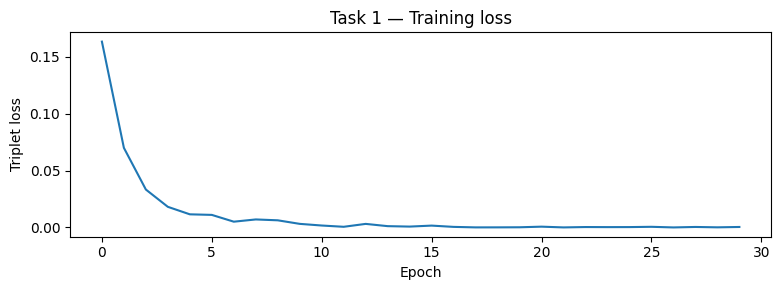

In [6]:
# Task 1.3: Training

def train_model(train_dataset, embed_dim=128, P=10, K=4,
                n_epochs=30, lr=3e-4, margin=0.3, device=DEVICE):

    model = EmbeddingNet(embed_dim=embed_dim).to(device)
    criterion = OnlineTripletLoss(margin=margin)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

    sampler = BalancedBatchSampler(train_dataset, P=P, K=K)
    loader  = DataLoader(train_dataset, batch_sampler=sampler, num_workers=0)

    history = []
    for epoch in range(1, n_epochs + 1):
        model.train()
        batch_losses = []
        for images, labels in loader:
            images = images.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        scheduler.step()
        avg = float(np.mean(batch_losses))
        history.append(avg)
        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}/{n_epochs}  |  loss: {avg:.4f}")

    return model, history


model, history = train_model(train_data)

plt.figure(figsize=(8, 3))
plt.plot(history)
plt.xlabel("Epoch"); plt.ylabel("Triplet loss")
plt.title("Task 1 — Training loss"); plt.tight_layout(); plt.show()

In [7]:
# Embedding extraction utility
@torch.no_grad()
def extract_embeddings(model, dataset, device=DEVICE, batch_size=64):
    """
    Run dataset through model; return (embeddings, labels) as numpy arrays.
    """

    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    embs, lbls = [], []
    for images, labels in loader:
        embs.append(model(images.to(device)).cpu())
        lbls.append(labels)

    return torch.cat(embs).numpy(), torch.cat(lbls).numpy()

In [ ]:
# Task 1.4: k-NN classification on SEEN items

# Method:
# Gallery  = all training images embedded by the model
# Query    = test images (unseen camera angles)
# Decision = label of the nearest neighbor in the gallery (1-NN)

# Triplet loss trained the space so same-item images cluster together. No retraining needed, just nearest neighbor lookup.

train_embs, train_labels = extract_embeddings(model, train_data)
test_embs,  test_labels  = extract_embeddings(model, test_data)

knn = KNeighborsClassifier(n_neighbors=1, metric="euclidean")
knn.fit(train_embs, train_labels)
acc_seen = accuracy_score(test_labels, knn.predict(test_embs))

print(f"\n[Task 1.4] Seen-item 1-NN accuracy (target > 90%):  {acc_seen*100:.2f}%")


[Task 1.4] Seen-item 1-NN accuracy (target > 90%):  94.80%


In [ ]:
# Task 1.5: Prototype classification on UNSEEN items

# Method (Prototypical Networks inference):
#   Prototype = mean embedding of all support images for that class
#   Decision  = label of the nearest prototype
#
# Works WITHOUT retraining: the model learned a general visual similarity metric during training, which transfers to new classes it never saw.
# Two unseen apple varieties will be separated if they look visually different, because the model learned to separate visually different things in general.

support_embs, support_labels   = extract_embeddings(model, support_new_data)
test_new_embs, test_new_labels  = extract_embeddings(model, test_new_data)

# One prototype per unseen class = mean of its support embeddings
unique_cls = np.unique(support_labels)
prototypes = np.stack([support_embs[support_labels == c].mean(0)
                       for c in unique_cls])

# Re-normalize: mean of unit vectors is not necessarily unit length
prototypes = prototypes / (np.linalg.norm(prototypes, axis=1, keepdims=True) + 1e-8)

# Nearest prototype decision
dists = np.linalg.norm(test_new_embs[:, None] - prototypes[None], axis=2)
pred_new_labels = unique_cls[dists.argmin(axis=1)]
acc_unseen = accuracy_score(test_new_labels, pred_new_labels)

print(f"[Task 1.5] Unseen-item prototype accuracy (target > 80%): {acc_unseen*100:.2f}%")

[Task 1.5] Unseen-item prototype accuracy (target > 80%): 86.56%


## Task 2

In [8]:
class GardenDataset(Dataset):
    def __init__(self, transform=None, class_level="item", subset="train", family_subset="main", item_subset="main"):
        assert class_level in ["item","family","both"]
        assert subset in ["train","test"]
        assert family_subset in ["main","new","all"]
        assert item_subset in ["main","new","all"]
        path = kagglehub.dataset_download("moltean/fruits")
        base = Path(path) / "fruits-360_original-size" / "fruits-360-original-size"
        if subset == "train":
            self.path = base / "Training"
        elif subset == "test":
            self.path = base / "Validation"
        self.transform = transform
        self.class_level = class_level

        canonical_items = sorted(
            d for d in os.listdir(base / "Training")
            if (base / "Training" / d).is_dir() and re.fullmatch(r'\S+ \d+', d)
        )
        item_to_family = {it: it.rsplit(' ', 1)[0] for it in canonical_items}
        canonical_families = sorted(set(item_to_family.values()))

        self.item_to_idx = {c: i for i, c in enumerate(canonical_items)}
        self.family_to_idx = {c: i for i, c in enumerate(canonical_families)}

        train_fam_to_items = defaultdict(list)
        for it in canonical_items:
            train_fam_to_items[item_to_family[it]].append(it)
        for fam in train_fam_to_items:
            train_fam_to_items[fam].sort(key=lambda x: int(x.rsplit(' ', 1)[1]))

        new_families = {fam for fam, its in train_fam_to_items.items() if len(its) == 1}
        new_items = set()
        for fam, its in train_fam_to_items.items():
            if len(its) >= 3:
                new_items.add(its[0])

        present = {
            d for d in os.listdir(self.path)
            if (self.path / d).is_dir() and re.fullmatch(r'\S+ \d+', d)
        }
        all_items = [it for it in canonical_items if it in present]

        if family_subset == "main":
            all_items = [it for it in all_items if item_to_family[it] not in new_families]
        elif family_subset == "new":
            all_items = [it for it in all_items if item_to_family[it] in new_families]

        if item_subset == "main":
            all_items = [it for it in all_items if it not in new_items]
        elif item_subset == "new":
            all_items = [it for it in all_items if it in new_items]

        self.items = all_items
        self.item_to_family = {it: item_to_family[it] for it in self.items}
        self.families = sorted(set(self.item_to_family.values()))
        self.new_families = new_families
        self.new_items = new_items

        # Build samples using canonical (global) indices
        self.image_paths = []
        self.targets_item = []
        self.targets_family = []
        for item in self.items:
            item_dir = self.path / item
            item_label = self.item_to_idx[item]
            family_label = self.family_to_idx[item_to_family[item]]
            for img_file in sorted(os.listdir(item_dir)):
                if img_file.endswith('.jpg'):
                    self.image_paths.append(item_dir / img_file)
                    self.targets_item.append(item_label)
                    self.targets_family.append(family_label)

        if class_level == "item":
            self.classes = self.items
            self.class_to_idx = self.item_to_idx
            self.targets = self.targets_item
        elif class_level == "family":
            self.classes = self.families
            self.class_to_idx = self.family_to_idx
            self.targets = self.targets_family

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        if self.class_level == "both":
             return image, self.targets_family[idx], self.targets_item[idx]
        return image, self.targets[idx]

    def get_items_for_family(self, family):
        return sorted(item for item, fam in self.item_to_family.items() if fam == family)

dataset = GardenDataset()

family_dd = widgets.Dropdown(options=dataset.families, description="Family:")
item_dd = widgets.Dropdown(options=dataset.get_items_for_family(dataset.families[0]), description="Item:")
frame_slider = widgets.IntSlider(value=0, min=0, max=0, description="Frame:")
output = widgets.Output()


def get_frames(item):
    return sorted(f for f in os.listdir(dataset.path / item) if f.endswith(".jpg"))

def update_items(*_):
    items = dataset.get_items_for_family(family_dd.value)
    item_dd.options = items
    item_dd.value = items[0]

def update_slider(*_):
    frames = get_frames(item_dd.value)
    frame_slider.max = max(0, len(frames) - 1)
    frame_slider.value = min(frame_slider.value, frame_slider.max)
    show_image()

def show_image(*_):
    frames = get_frames(item_dd.value)
    if not frames or frame_slider.value >= len(frames):
        return
    with output:
        clear_output(wait=True)
        img = Image.open(dataset.path / item_dd.value / frames[frame_slider.value])
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(img)
        ax.set_title(f"{family_dd.value} | {item_dd.value} | frame {frame_slider.value}")
        ax.axis("off")
        plt.tight_layout()
        plt.show()

family_dd.observe(update_items, names="value")
item_dd.observe(update_slider, names="value")
frame_slider.observe(show_image, names="value")

update_slider()
display(widgets.VBox([family_dd, item_dd, frame_slider, output]))

In [9]:
train_data = GardenDataset(subset="train", transform=transform)

# scenario 1
test_data = GardenDataset(subset="test", transform=transform)

# scenario 2
train_data_family = GardenDataset(subset="train", transform=transform, class_level="family")
test_data_family = GardenDataset(subset="test", transform=transform, class_level="family")

# scenario 3
support_all_data = GardenDataset(subset="train", transform=transform, item_subset="all")
test_new_data = GardenDataset(subset="test", transform=transform, item_subset="new")

# scenario 4
support_all_data_family = GardenDataset(subset="train", transform=transform, family_subset="all",class_level="family")
test_new_data_family = GardenDataset(subset="test", transform=transform, family_subset="new",class_level="family")

# your code here



Epoch   1/30  |  loss: 0.1226
Epoch   5/30  |  loss: 0.0617
Epoch  10/30  |  loss: 0.0357
Epoch  15/30  |  loss: 0.0343
Epoch  20/30  |  loss: 0.0241
Epoch  25/30  |  loss: 0.0287
Epoch  30/30  |  loss: 0.0276


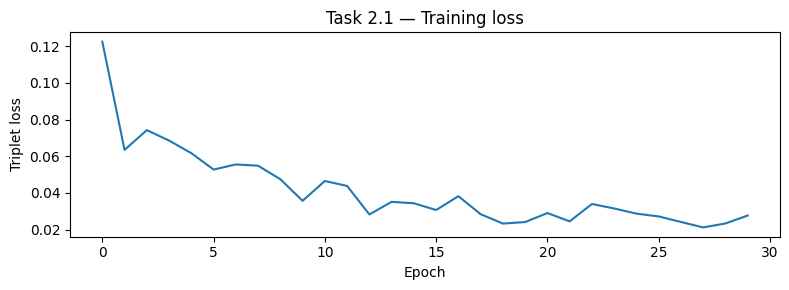

In [10]:
model, history = train_model(train_data)

plt.figure(figsize=(8, 3))
plt.plot(history)
plt.xlabel("Epoch"); plt.ylabel("Triplet loss")
plt.title("Task 2.1 — Training loss"); plt.tight_layout(); plt.show()

In [11]:
def extract_embeddings(model, dataset, device=DEVICE, batch_size=256):
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    embs, lbls = [], []
    with torch.no_grad():
        for images, labels in loader:
            embs.append(model(images.to(device)).cpu())
            lbls.append(labels)
    return torch.cat(embs).numpy(), torch.cat(lbls).numpy()

step 0.5 finihed
step 1 finihed

[Task 2.1] Seen-item 1-NN accuracy (target > 90%):  100.00%


In [12]:

##scenario 1
train_embs1, train_labels1 = extract_embeddings(model, train_data)

test_embs1,  test_labels1  = extract_embeddings(model, test_data)
knn = KNeighborsClassifier(n_neighbors=1, metric="euclidean", )
knn.fit(train_embs1, train_labels1)
test_preds1 = knn.predict(test_embs1)
acc_seen = accuracy_score(test_labels1, knn.predict(test_embs1))

print(f"\n[scenario 1] Seen-item 1-NN accuracy (target > 90%):  {acc_seen*100:.2f}%")
## scenario 2
train_embs2, train_labels2 = extract_embeddings(model, train_data_family)

test_embs2,  test_labels2  = extract_embeddings(model, test_data_family)
knn = KNeighborsClassifier(n_neighbors=1, metric="euclidean", )
knn.fit(train_embs2, train_labels2)
test_preds2 = knn.predict(test_embs2)
acc_seen = accuracy_score(test_labels2, knn.predict(test_embs2))

print(f"\n[scenario 2] Seen-item 1-NN accuracy (target > 90%):  {acc_seen*100:.2f}%")

## scenario 3
train_embs3, train_labels3 = extract_embeddings(model, support_all_data)

test_embs3,  test_labels3  = extract_embeddings(model, test_new_data)
knn = KNeighborsClassifier(n_neighbors=1, metric="euclidean", )
knn.fit(train_embs3, train_labels3)
test_preds3 = knn.predict(test_embs3)
acc_seen = accuracy_score(test_labels3, test_preds3)

print(f"\n[scenario 3] Seen-item 1-NN accuracy (target > 90%):  {acc_seen*100:.2f}%")

## scenario 4

train_embs4, train_labels4 = extract_embeddings(model, support_all_data_family)

test_embs4,  test_labels4  = extract_embeddings(model, test_new_data_family)
knn = KNeighborsClassifier(n_neighbors=1, metric="euclidean", )
knn.fit(train_embs4, train_labels4)
test_preds4 = knn.predict(test_embs4)
acc_seen = accuracy_score(test_labels4, knn.predict(test_embs4))

print(f"\n[scenario 4] Seen-item 1-NN accuracy (target > 90%):  {acc_seen*100:.2f}%")


[scenario 1] Seen-item 1-NN accuracy (target > 90%):  100.00%

[scenario 2] Seen-item 1-NN accuracy (target > 90%):  100.00%

[scenario 3] Seen-item 1-NN accuracy (target > 90%):  100.00%

[scenario 4] Seen-item 1-NN accuracy (target > 90%):  100.00%


In [19]:
from collections import defaultdict

family_acc_dict= defaultdict(list)
for true_item, pred_item, family in zip(test_labels1, test_preds1, test_labels2):
  family_acc_dict[family].append(true_item== pred_item)

families = list(family_acc_dict.keys())
accuracies = [np.mean(family_acc_dict[f])*100 for f in families]
family_names = test_data_family.classes
plt.figure(figsize=(12, 4))
plt.bar([family_names[f] for f in families], accuracies)
plt.xlabel("Family")
plt.ylabel("Accuracy (%)")
plt.title("Scenario 1 - Item classification accuracy per family")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

IndexError: list index out of range

<Figure size 1200x400 with 0 Axes>

In [24]:
families

[np.int64(1),
 np.int64(2),
 np.int64(4),
 np.int64(10),
 np.int64(11),
 np.int64(15),
 np.int64(17),
 np.int64(19),
 np.int64(20),
 np.int64(21),
 np.int64(23),
 np.int64(24),
 np.int64(25),
 np.int64(26),
 np.int64(27)]

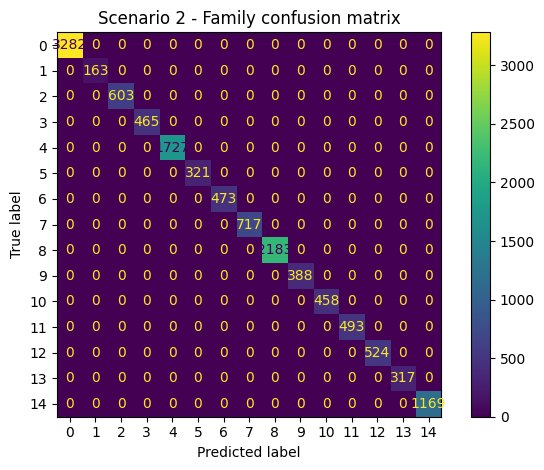

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
knn_fam = KNeighborsClassifier(n_neighbors=1, metric="cosine")
knn_fam.fit(train_embs2, train_labels2)
test_preds_fam = knn_fam.predict(test_embs2)

# plot confusion matrix
cm = confusion_matrix(test_labels2, test_preds2)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Scenario 2 - Family confusion matrix")
plt.tight_layout()
plt.show()

## Task 3

In [ ]:
train_data_both = GardenDataset(class_level="both",transform=transform,subset="train",family_subset="main",item_subset="main")

test_data_both = GardenDataset(class_level="both",transform=transform,subset="test",family_subset="main",item_subset="main")

# your code here

## Task 4

In [ ]:
class BlackoutPixels:
    """Transform that randomly sets x% of pixels to black (0).

    Args:
        fraction: Fraction of pixels to black out (0.0 to 1.0).
    """
    def __init__(self, fraction=0.1):
        self.fraction = fraction

    def __call__(self, img):
        # img shape: (C, H, W)
        _, h, w = img.shape
        num_pixels = h * w
        num_black = int(num_pixels * self.fraction)

        # Random pixel indices to black out
        indices = torch.randperm(num_pixels)[:num_black]
        rows = indices // w
        cols = indices % w

        img = img.clone()
        img[:, rows, cols] = 0.0
        return img

def get_anomaly_dataset(fraction):
    transform = transforms.Compose([
        BlackoutPixels(fraction=fraction),
        ... # your transforms here
    ])
    return GardenDataset(subset="test", transform=transform, family_subset="main", item_subset="main")

# your code here
